<a href="https://colab.research.google.com/github/itmitev/blinkit_sales_repository/blob/main/python/Blinkit_ML_ROAS_decomposition.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
# =============================================================================
# BLINKIT MARKETING ROAS DRIVER ANALYSIS
# Single model: Gradient Boosting Regression + SHAP explainability
#
# Table used (exact schema):
#   marketing_performance:
#     campaign_id, campaign_name, date, target_audience, channel,
#     impressions, clicks, conversions, spend, revenue_generated, roas
#
# Business question: Which campaign characteristics drive high ROAS,
# and how should we reallocate budget to maximise return?
#
# Paste into Google Colab and run top to bottom.
# =============================================================================

In [7]:
# ── 0. INSTALL & IMPORTS ─────────────────────────────────────────────────────
!pip install xgboost shap sqlalchemy psycopg2-binary -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.preprocessing import LabelEncoder
import shap

plt.rcParams["figure.dpi"]      = 130
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

In [8]:
# ── 1. LOAD DATA ──────────────────────────────────────────────────────────────
# Supabase connection code:

from google.colab import userdata
from sqlalchemy import create_engine
import pandas as pd

# Pull credentials from Secrets — never hardcode passwords
host     = userdata.get('SUPABASE_HOST')
password = userdata.get('SUPABASE_PASSWORD')

#connection_string = (
#    f"postgresql://postgres:{password}"
#    f"@{host}:5432/postgres?sslmode=require"
#)

connection_string = (
    f"postgresql://postgres.khcnudaxsvauxbirokmo:{password}"
    f"@{host}:6543/postgres"
)

engine = create_engine(connection_string)

# Test the connection
try:
    test = pd.read_sql("SELECT COUNT(*) FROM marketing_performance", engine)
    print(f"✅ Connected. Rows in marketing_performance: {test.iloc[0,0]}")
except Exception as e:
    print(f"❌ Connection failed: {e}")

df = pd.read_sql("SELECT * FROM marketing_performance", engine)

print(f"Rows: {len(df)}")
print(f"Columns: {df.columns.tolist()}")
print(f"\nSample:")
print(df.head(3).to_string())
print(f"\nChannels     : {df['channel'].unique().tolist()}")
print(f"Audiences    : {df['target_audience'].unique().tolist()}")
print(f"Date range   : {df['date'].min()} → {df['date'].max()}")
print(f"\nMissing values:\n{df.isnull().sum()}")

✅ Connected. Rows in marketing_performance: 5400
Rows: 5400
Columns: ['campaign_id', 'campaign_name', 'date', 'target_audience', 'channel', 'impressions', 'clicks', 'conversions', 'spend', 'revenue_generated', 'roas']

Sample:
   campaign_id      campaign_name        date target_audience channel  impressions  clicks  conversions    spend  revenue_generated  roas
0       548299  New User Discount  2024-11-05         Premium     App         3130     163           78  1431.85            4777.75  3.60
1       390914    Weekend Special  2024-11-05        Inactive     App         3925     494           45  4506.34            6238.11  2.98
2       834385     Festival Offer  2024-11-05        Inactive   Email         7012     370           78  4524.23            2621.00  2.95

Channels     : ['App', 'Email', 'SMS', 'Social Media']
Audiences    : ['Premium', 'Inactive', 'New Users', 'All']
Date range   : 2023-03-17 → 2024-11-05

Missing values:
campaign_id          0
campaign_name        0
date

In [9]:
# ── 2. CLEAN & VALIDATE ───────────────────────────────────────────────────────

df["date"] = pd.to_datetime(df["date"])

# Remove rows where spend is zero (division-by-zero in ROAS)
df = df[df["spend"] > 0].copy()

# Recalculate ROAS from source columns — don't trust a pre-computed field
# to be consistent across all rows
df["roas_calc"] = df["revenue_generated"] / df["spend"]

# Flag if the provided roas column differs significantly from recalculated
discrepancy = (df["roas"] - df["roas_calc"]).abs()
if discrepancy.max() > 0.01:
    print(f"\n⚠ ROAS discrepancy detected (max diff={discrepancy.max():.4f})")
    print("  Using recalculated ROAS (revenue_generated / spend) as target.")
    df["roas_target"] = df["roas_calc"]
else:
    df["roas_target"] = df["roas"]

print(f"\nROAS stats:")
print(df["roas_target"].describe().round(3))

# Remove extreme outliers (ROAS > 99th percentile) — likely data errors
p99 = df["roas_target"].quantile(0.99)
p01 = df["roas_target"].quantile(0.01)
outliers = df[(df["roas_target"] > p99) | (df["roas_target"] < p01)]
if len(outliers) > 0:
    print(f"\nRemoving {len(outliers)} outlier campaigns (ROAS outside [{p01:.2f}, {p99:.2f}])")
    df = df[(df["roas_target"] <= p99) & (df["roas_target"] >= p01)].copy()


⚠ ROAS discrepancy detected (max diff=7.7624)
  Using recalculated ROAS (revenue_generated / spend) as target.

ROAS stats:
count    5400.000
mean        2.380
std         1.560
min         0.409
25%         1.290
50%         1.966
75%         2.939
max         9.681
Name: roas_target, dtype: float64

Removing 108 outlier campaigns (ROAS outside [0.50, 7.87])


In [10]:
# ── 3. FEATURE ENGINEERING ───────────────────────────────────────────────────
# Build interpretable features from the raw columns.
# Every feature here has a clear business meaning — important for the
# SHAP narrative in the dashboard.

# Funnel efficiency metrics
df["ctr"]        = df["clicks"]      / df["impressions"].clip(lower=1)   # click-through rate
df["cvr"]        = df["conversions"] / df["clicks"].clip(lower=1)        # conversion rate
df["cpc"]        = df["spend"]       / df["clicks"].clip(lower=1)        # cost per click
df["cpa"]        = df["spend"]       / df["conversions"].clip(lower=1)   # cost per acquisition
df["rev_per_conv"] = df["revenue_generated"] / df["conversions"].clip(lower=1)

# Scale / size features
df["log_spend"]       = np.log1p(df["spend"])          # log-transform to handle skew
df["log_impressions"] = np.log1p(df["impressions"])

# Temporal features from the date column
df["month"]        = df["date"].dt.month
df["quarter"]      = df["date"].dt.quarter
df["day_of_week"]  = df["date"].dt.dayofweek
df["is_weekend"]   = (df["day_of_week"] >= 5).astype(int)

# Encode categorical columns as integers
# Using pandas category codes — simple and transparent
le_channel  = LabelEncoder()
le_audience = LabelEncoder()

df["channel_enc"]  = le_channel.fit_transform(df["channel"].astype(str))
df["audience_enc"] = le_audience.fit_transform(df["target_audience"].astype(str))

# Print channel → integer mapping so SHAP chart is readable
channel_map  = dict(zip(le_channel.classes_,
                         le_channel.transform(le_channel.classes_)))
audience_map = dict(zip(le_audience.classes_,
                         le_audience.transform(le_audience.classes_)))
print(f"\nChannel encoding  : {channel_map}")
print(f"Audience encoding : {audience_map}")


Channel encoding  : {'App': np.int64(0), 'Email': np.int64(1), 'SMS': np.int64(2), 'Social Media': np.int64(3)}
Audience encoding : {'All': np.int64(0), 'Inactive': np.int64(1), 'New Users': np.int64(2), 'Premium': np.int64(3)}


In [11]:
# ── 4. DEFINE FEATURE MATRIX ──────────────────────────────────────────────────

feature_cols = [
    # Campaign configuration
    "channel_enc",       # which channel — strongest categorical predictor
    "audience_enc",      # which audience segment was targeted
    # Funnel efficiency
    "ctr",               # did the ad attract attention?
    "cvr",               # did clicks convert?
    "cpc",               # how expensive was each click?
    "cpa",               # how expensive was each conversion?
    # Scale
    "log_spend",         # campaign size (log-transformed)
    "log_impressions",   # reach
    # Timing
    "month",             # seasonality
    "quarter",
    "is_weekend",
]

X = df[feature_cols].fillna(0)
y = df["roas_target"]

print(f"\nFeature matrix: {X.shape}")
print(f"Target (ROAS): mean={y.mean():.2f}, std={y.std():.2f}, min={y.min():.2f}, max={y.max():.2f}")



Feature matrix: (5292, 11)
Target (ROAS): mean=2.34, std=1.43, min=0.50, max=7.87


In [12]:
# ── 5. TRAIN / TEST SPLIT & MODEL ────────────────────────────────────────────

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = GradientBoostingRegressor(
    n_estimators  = 300,
    max_depth     = 4,
    learning_rate = 0.05,
    subsample     = 0.8,
    min_samples_leaf = 5,
    random_state  = 42
)
model.fit(X_train, y_train)

# Evaluation
y_pred      = model.predict(X_test)
r2          = r2_score(y_test, y_pred)
mae         = mean_absolute_error(y_test, y_pred)
cv_scores   = cross_val_score(model, X, y, cv=5, scoring="r2")

print("\n" + "="*50)
print("MODEL PERFORMANCE")
print("="*50)
print(f"  R²  (test set)          : {r2:.3f}")
print(f"  MAE (test set)          : {mae:.3f} ROAS points")
print(f"  R²  (5-fold CV, mean)   : {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")
print(f"\nInterpretation:")
print(f"  The model explains {r2*100:.0f}% of ROAS variance.")
print(f"  Average prediction error: ±{mae:.2f}x ROAS")


MODEL PERFORMANCE
  R²  (test set)          : 0.487
  MAE (test set)          : 0.825 ROAS points
  R²  (5-fold CV, mean)   : 0.499 ± 0.024

Interpretation:
  The model explains 49% of ROAS variance.
  Average prediction error: ±0.82x ROAS


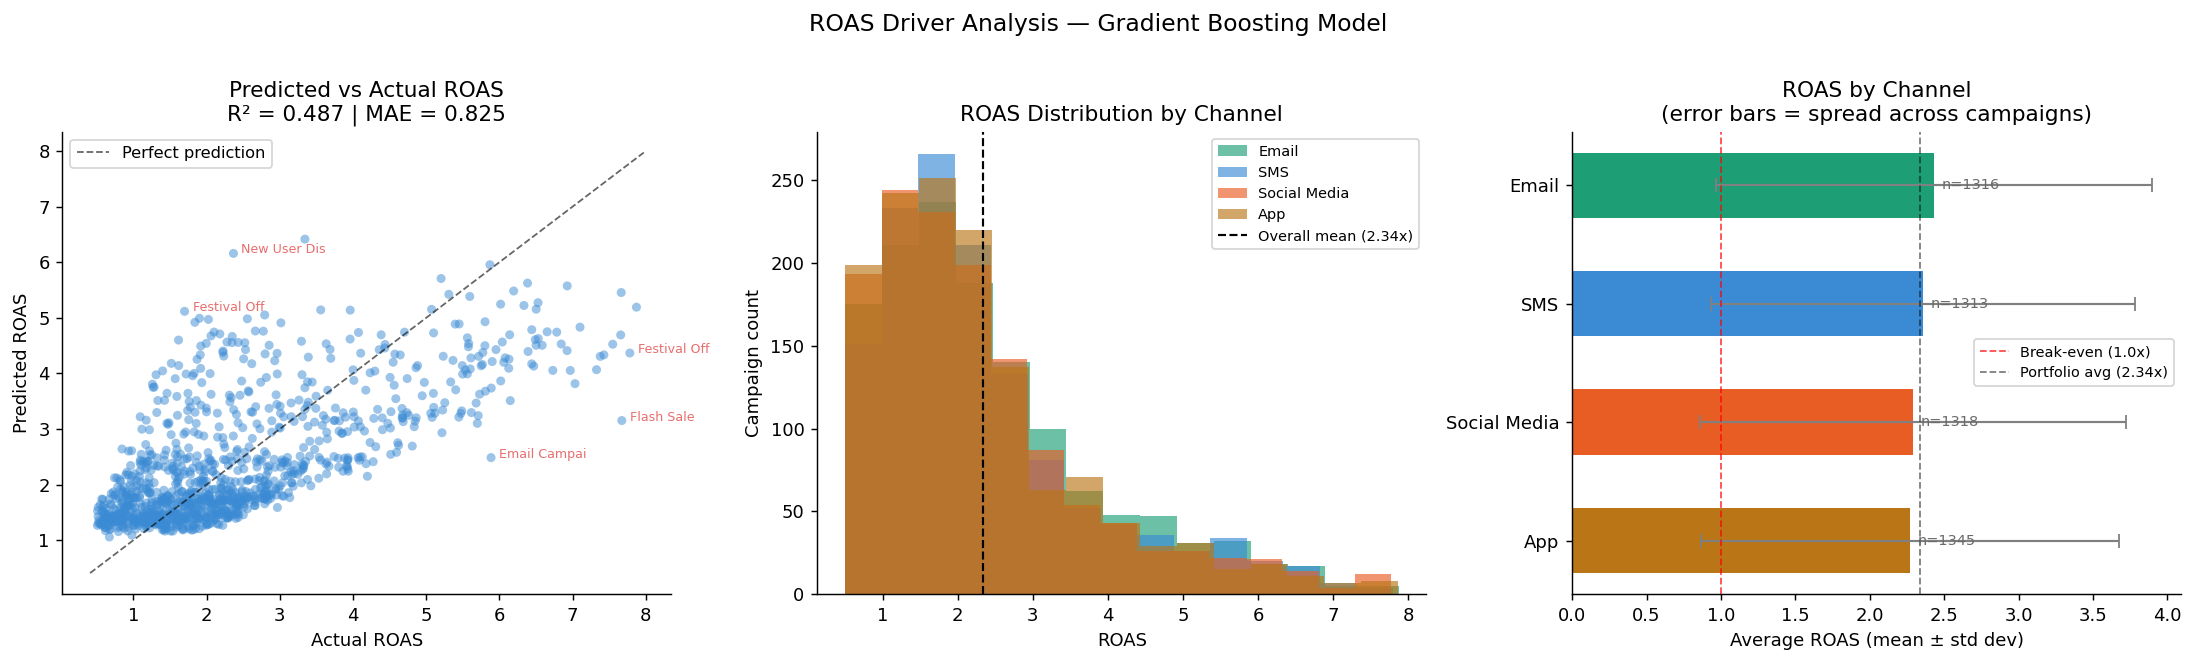

In [14]:
# ── 6. PLOTS ──────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle("ROAS Driver Analysis — Gradient Boosting Model", fontsize=13, y=1.01)

# ── Plot 1: Predicted vs Actual ROAS ─────────────────────────────────────────
axes[0].scatter(y_test, y_pred, alpha=0.5, s=25, color="#3B8BD4", edgecolors="none")
lims = [min(y_test.min(), y_pred.min()) - 0.1,
        max(y_test.max(), y_pred.max()) + 0.1]
axes[0].plot(lims, lims, "k--", linewidth=1, alpha=0.6, label="Perfect prediction")
axes[0].set_xlabel("Actual ROAS")
axes[0].set_ylabel("Predicted ROAS")
axes[0].set_title(f"Predicted vs Actual ROAS\nR² = {r2:.3f} | MAE = {mae:.3f}")
axes[0].legend(fontsize=9)

# Annotate outliers — campaigns where model is most wrong
residuals = y_pred - y_test.values
top_errors = np.argsort(np.abs(residuals))[-5:]
for idx in top_errors:
    axes[0].annotate(
        f"  {df.iloc[y_test.index[idx]]['campaign_name'][:12]}",
        xy=(y_test.values[idx], y_pred[idx]),
        fontsize=7, color="#E24B4A", alpha=0.8
    )

# ── Plot 2: ROAS distribution by channel ──────────────────────────────────────
channel_order = (df.groupby("channel")["roas_target"]
                   .median().sort_values(ascending=False).index)
channel_colors = {ch: c for ch, c in zip(
    channel_order,
    ["#1D9E75","#3B8BD4","#E85D24","#BA7517","#534AB7","#D4537E","#888780"]
)}
for ch in channel_order:
    data = df[df["channel"] == ch]["roas_target"]
    axes[1].hist(data, bins=15, alpha=0.65, label=ch,
                 color=channel_colors.get(ch, "#888"))
axes[1].axvline(df["roas_target"].mean(), color="black",
                linestyle="--", linewidth=1.2, label=f"Overall mean ({df['roas_target'].mean():.2f}x)")
axes[1].set_xlabel("ROAS")
axes[1].set_ylabel("Campaign count")
axes[1].set_title("ROAS Distribution by Channel")
axes[1].legend(fontsize=8)

# ── Plot 3: Channel-level ROAS summary (mean ± std) ───────────────────────────
ch_stats = (df.groupby("channel")["roas_target"]
              .agg(["mean","std","count"])
              .rename(columns={"mean":"avg_roas","std":"std_roas","count":"n"})
              .sort_values("avg_roas", ascending=True))

bars = axes[2].barh(
    ch_stats.index, ch_stats["avg_roas"],
    xerr=ch_stats["std_roas"],
    color=[channel_colors.get(c,"#888") for c in ch_stats.index],
    height=0.55, error_kw={"elinewidth":1.2,"capsize":4,"ecolor":"gray"}
)
axes[2].axvline(1.0, color="red", linestyle="--", linewidth=1,
                alpha=0.7, label="Break-even (1.0x)")
axes[2].axvline(df["roas_target"].mean(), color="black",
                linestyle="--", linewidth=1, alpha=0.5,
                label=f"Portfolio avg ({df['roas_target'].mean():.2f}x)")
for bar, (_, row) in zip(bars, ch_stats.iterrows()):
    axes[2].text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2,
                 f"n={int(row['n'])}", va="center", fontsize=8,
                 color="#6A6A6A") # Changed from 'var(--color-text-secondary)' to '#6A6A6A'
axes[2].set_xlabel("Average ROAS (mean ± std dev)")
axes[2].set_title("ROAS by Channel\n(error bars = spread across campaigns)")
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.savefig("roas_model_overview.png", dpi=150, bbox_inches="tight")
plt.show()

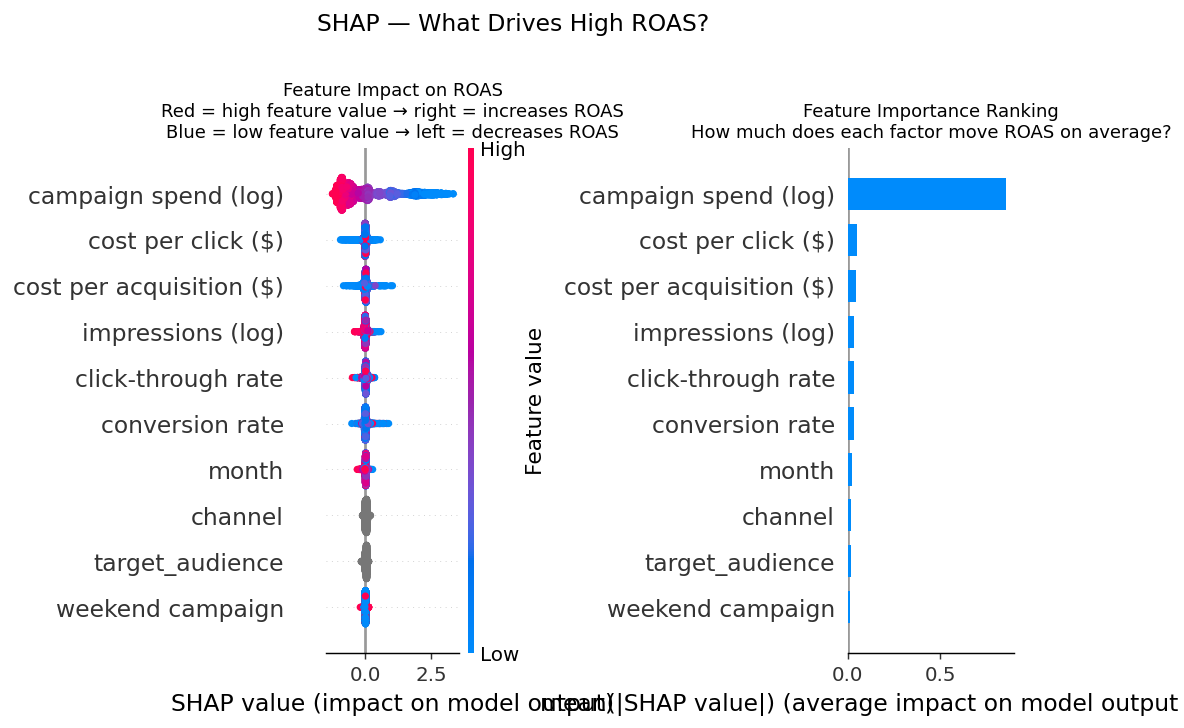


TOP ROAS DRIVERS — PLAIN ENGLISH SUMMARY
  1. campaign spend (log)           avg impact: ±0.857x ROAS
  2. cost per click ($)             avg impact: ±0.048x ROAS
  3. cost per acquisition ($)       avg impact: ±0.043x ROAS
  4. impressions (log)              avg impact: ±0.036x ROAS
  5. click-through rate             avg impact: ±0.036x ROAS


In [15]:
# ── 7. SHAP EXPLAINABILITY ────────────────────────────────────────────────────
# The most important output for the business narrative.
# Answers: "what makes a campaign produce high ROAS?"

explainer   = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X)

# Map encoded values back to readable labels for the chart
X_display = X.copy()
X_display["channel_enc"]  = df["channel"]
X_display["audience_enc"] = df["target_audience"]
X_display = X_display.rename(columns={
    "channel_enc"  : "channel",
    "audience_enc" : "target_audience",
    "ctr"          : "click-through rate",
    "cvr"          : "conversion rate",
    "cpc"          : "cost per click ($)",
    "cpa"          : "cost per acquisition ($)",
    "log_spend"    : "campaign spend (log)",
    "log_impressions": "impressions (log)",
    "month"        : "month",
    "quarter"      : "quarter",
    "is_weekend"   : "weekend campaign",
})

fig, axes = plt.subplots(1, 2, figsize=(17, 6))
fig.suptitle("SHAP — What Drives High ROAS?", fontsize=13, y=1.01)

# Left: beeswarm — direction and magnitude of each feature's impact
plt.sca(axes[0])
shap.summary_plot(
    shap_values, X_display,
    feature_names=X_display.columns.tolist(),
    show=False, plot_type="dot", max_display=10
)
axes[0].set_title("Feature Impact on ROAS\n"
                  "Red = high feature value → right = increases ROAS\n"
                  "Blue = low feature value → left = decreases ROAS",
                  fontsize=10)

# Right: mean |SHAP| bar — clean ranking for executives
plt.sca(axes[1])
shap.summary_plot(
    shap_values, X_display,
    feature_names=X_display.columns.tolist(),
    show=False, plot_type="bar", max_display=10
)
axes[1].set_title("Feature Importance Ranking\n"
                  "How much does each factor move ROAS on average?",
                  fontsize=10)

plt.tight_layout()
plt.savefig("shap_roas_drivers.png", dpi=150, bbox_inches="tight")
plt.show()

# Print top 3 insights in plain English
mean_abs_shap = pd.Series(
    np.abs(shap_values).mean(axis=0),
    index=X_display.columns
).sort_values(ascending=False)

print("\n" + "="*55)
print("TOP ROAS DRIVERS — PLAIN ENGLISH SUMMARY")
print("="*55)
for i, (feat, val) in enumerate(mean_abs_shap.head(5).items(), 1):
    direction = "increases" if shap_values[:, list(X_display.columns).index(feat)].mean() > 0 \
                else "decreases"
    print(f"  {i}. {feat:<30} avg impact: ±{val:.3f}x ROAS")


CHANNEL PERFORMANCE SUMMARY
     channel  total_spend  total_revenue  avg_roas  avg_ctr  avg_cvr   avg_cpa  spend_share_pct  revenue_share_pct
       Email   3927975.46     8014317.78  2.431897 0.148746 0.138777 74.932052        24.539399          25.384682
         SMS   3911000.66     7801471.04  2.357184 0.142642 0.138454 77.208359        24.433352          24.710508
Social Media   4043138.06     7834838.52  2.288830 0.139759 0.145966 80.165792        25.258859          24.816197
         App   4124697.72     7920844.25  2.269931 0.136490 0.145100 79.642337        25.768390          25.088613


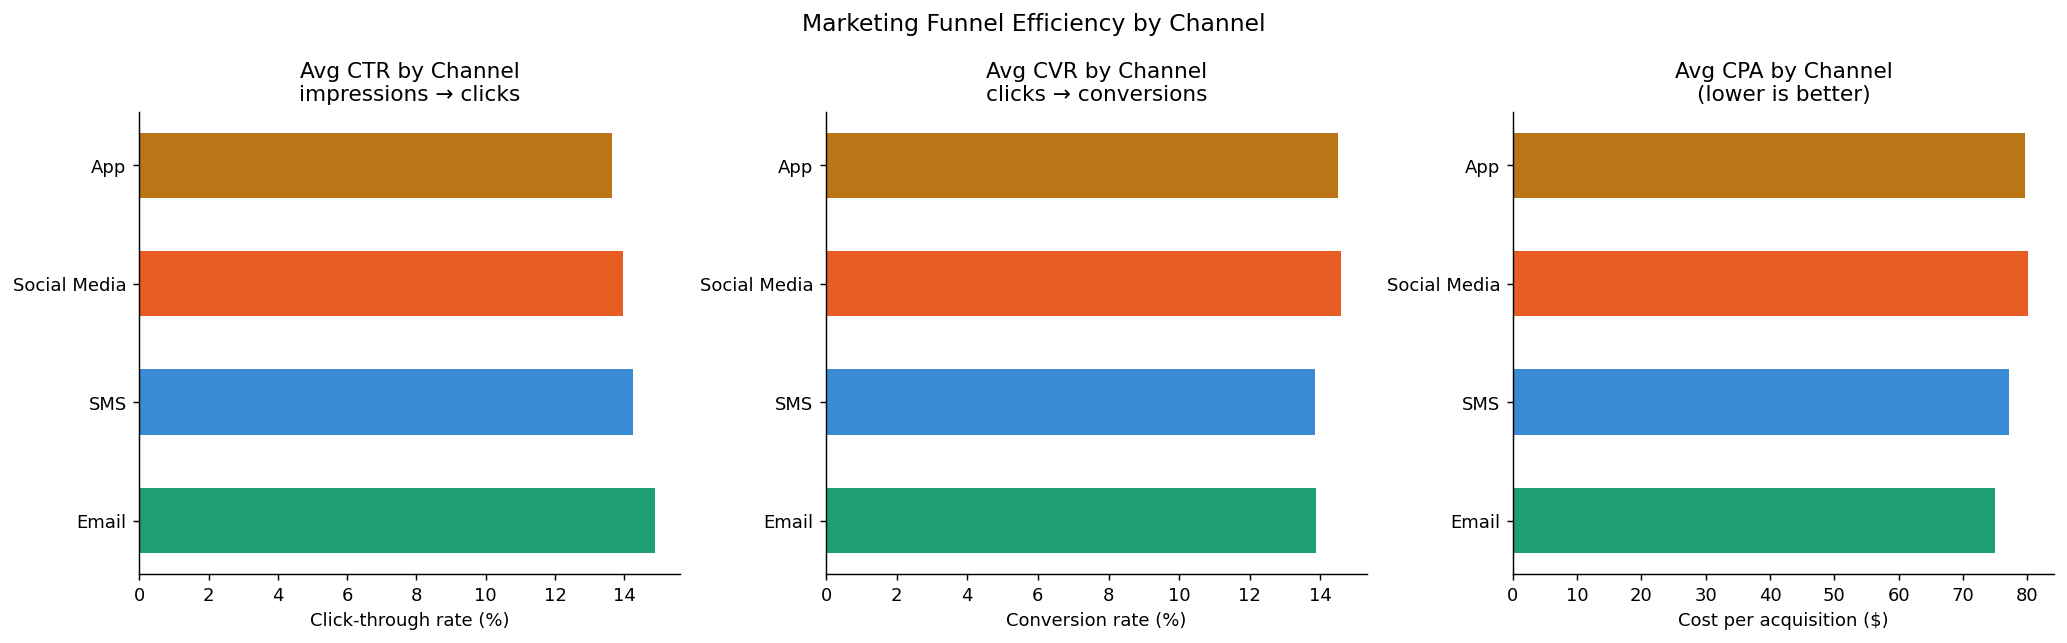

In [16]:
# ── 8. CHANNEL-LEVEL ROAS DEEP DIVE ──────────────────────────────────────────

channel_detail = df.groupby("channel").agg(
    total_spend        = ("spend",            "sum"),
    total_revenue      = ("revenue_generated","sum"),
    avg_roas           = ("roas_target",      "mean"),
    median_roas        = ("roas_target",      "median"),
    avg_ctr            = ("ctr",              "mean"),
    avg_cvr            = ("cvr",              "mean"),
    avg_cpa            = ("cpa",              "mean"),
    total_conversions  = ("conversions",      "sum"),
    n_campaigns        = ("campaign_id",      "count"),
).reset_index()

channel_detail["roi_on_spend"] = (
    channel_detail["total_revenue"] - channel_detail["total_spend"]
) / channel_detail["total_spend"]

channel_detail["spend_share_pct"] = (
    channel_detail["total_spend"] / channel_detail["total_spend"].sum() * 100
)
channel_detail["revenue_share_pct"] = (
    channel_detail["total_revenue"] / channel_detail["total_revenue"].sum() * 100
)

print("\n" + "="*55)
print("CHANNEL PERFORMANCE SUMMARY")
print("="*55)
print(channel_detail[[
    "channel","total_spend","total_revenue",
    "avg_roas","avg_ctr","avg_cvr","avg_cpa",
    "spend_share_pct","revenue_share_pct"
]].sort_values("avg_roas", ascending=False).to_string(index=False))

# Funnel breakdown chart
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Marketing Funnel Efficiency by Channel", fontsize=13)

channel_order_roas = channel_detail.sort_values("avg_roas", ascending=False)["channel"]

# Subplot 1: CTR
colors_ch = [channel_colors.get(c,"#888") for c in channel_order_roas]
axes[0].barh(channel_order_roas,
             channel_detail.set_index("channel").loc[channel_order_roas, "avg_ctr"] * 100,
             color=colors_ch, height=0.55)
axes[0].set_xlabel("Click-through rate (%)")
axes[0].set_title("Avg CTR by Channel\nimpressions → clicks")

# Subplot 2: CVR
axes[1].barh(channel_order_roas,
             channel_detail.set_index("channel").loc[channel_order_roas, "avg_cvr"] * 100,
             color=colors_ch, height=0.55)
axes[1].set_xlabel("Conversion rate (%)")
axes[1].set_title("Avg CVR by Channel\nclicks → conversions")

# Subplot 3: CPA
axes[2].barh(channel_order_roas,
             channel_detail.set_index("channel").loc[channel_order_roas, "avg_cpa"],
             color=colors_ch, height=0.55)
axes[2].set_xlabel("Cost per acquisition ($)")
axes[2].set_title("Avg CPA by Channel\n(lower is better)")

plt.tight_layout()
plt.savefig("funnel_by_channel.png", dpi=150, bbox_inches="tight")
plt.show()

In [17]:
# ── 9. AUDIENCE PERFORMANCE ───────────────────────────────────────────────────

audience_detail = df.groupby("target_audience").agg(
    avg_roas          = ("roas_target",      "mean"),
    total_spend       = ("spend",            "sum"),
    total_revenue     = ("revenue_generated","sum"),
    avg_cvr           = ("cvr",              "mean"),
    n_campaigns       = ("campaign_id",      "count"),
).reset_index().sort_values("avg_roas", ascending=False)

print("\n" + "="*55)
print("AUDIENCE PERFORMANCE SUMMARY")
print("="*55)
print(audience_detail.to_string(index=False))


AUDIENCE PERFORMANCE SUMMARY
target_audience  avg_roas  total_spend  total_revenue  avg_cvr  n_campaigns
       Inactive  2.381769   3972937.48     7931072.38 0.140377         1314
      New Users  2.369147   3990469.04     7934255.56 0.146492         1322
        Premium  2.322427   3983173.60     7811217.61 0.138507         1330
            All  2.273460   4060231.78     7894926.04 0.143011         1326



BUDGET REALLOCATION WHAT-IF (+20% SPEND PER CHANNEL)
     channel  current_spend  baseline_roas  roas_at_+20pct  roas_delta recommendation
Social Media     4043138.06       2.280727        1.955180   -0.325547       REDUCE ▼
         SMS     3911000.66       2.366158        2.017663   -0.348495       REDUCE ▼
         App     4124697.72       2.268104        1.919373   -0.348731       REDUCE ▼
       Email     3927975.46       2.403131        2.043321   -0.359810       REDUCE ▼


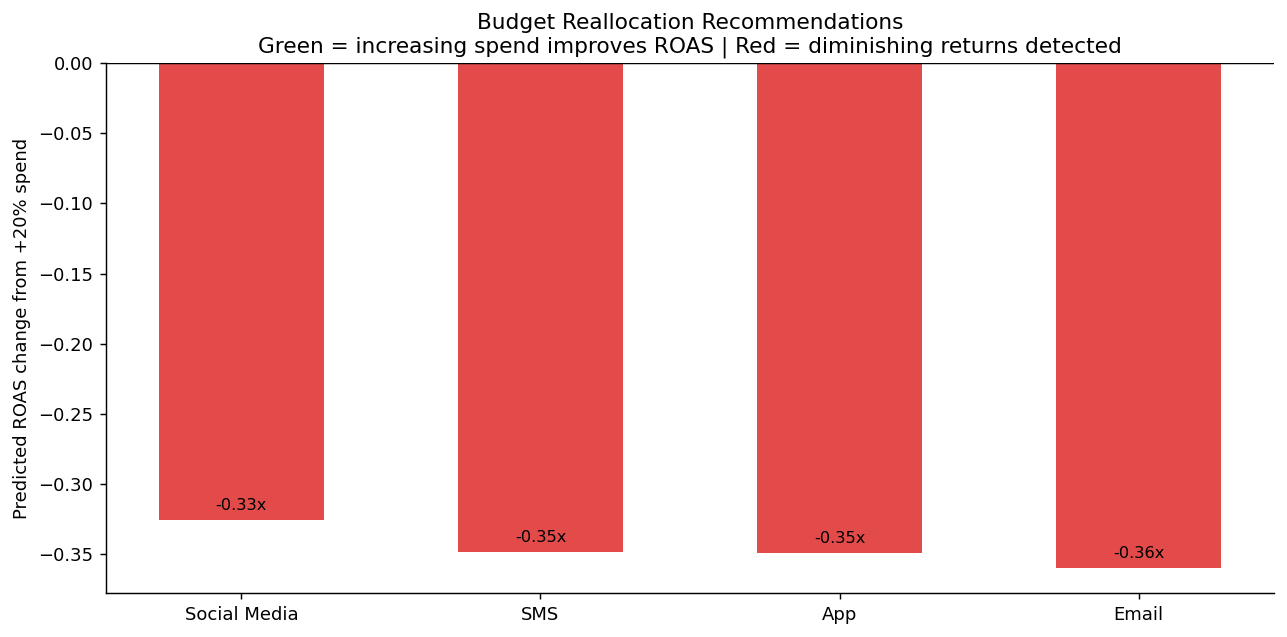

In [18]:
# ── 10. WHAT-IF: BUDGET REALLOCATION ─────────────────────────────────────────
# Predict ROAS under +20% spend increase per channel.
# Helps answer: "if we shift $X from channel A to channel B, what happens?"

print("\n" + "="*55)
print("BUDGET REALLOCATION WHAT-IF (+20% SPEND PER CHANNEL)")
print("="*55)

total_budget = df["spend"].sum()
recommendations = []

for ch in df["channel"].unique():
    ch_df = df[df["channel"] == ch].copy()

    # Baseline: average predicted ROAS at current spend
    ch_features = ch_df[feature_cols].fillna(0)
    baseline_roas = model.predict(ch_features).mean()

    # Simulate +20% spend (increase log_spend)
    ch_plus = ch_df.copy()
    ch_plus["log_spend"] = np.log1p(ch_df["spend"] * 1.2)
    plus_features = ch_plus[feature_cols].fillna(0)
    roas_plus20 = model.predict(plus_features).mean()

    # Simulate -20% spend
    ch_minus = ch_df.copy()
    ch_minus["log_spend"] = np.log1p(ch_df["spend"] * 0.8)
    minus_features = ch_minus[feature_cols].fillna(0)
    roas_minus20 = model.predict(minus_features).mean()

    current_spend  = ch_df["spend"].sum()
    roas_change    = roas_plus20 - baseline_roas
    action = ("INCREASE ▲" if roas_change > 0.1
              else "REDUCE ▼" if roas_change < -0.1
              else "MAINTAIN →")

    recommendations.append({
        "channel"         : ch,
        "current_spend"   : current_spend,
        "baseline_roas"   : baseline_roas,
        "roas_at_+20pct"  : roas_plus20,
        "roas_at_-20pct"  : roas_minus20,
        "roas_delta"      : roas_change,
        "recommendation"  : action,
    })

rec_df = pd.DataFrame(recommendations).sort_values("roas_delta", ascending=False)
print(rec_df[[
    "channel","current_spend","baseline_roas",
    "roas_at_+20pct","roas_delta","recommendation"
]].to_string(index=False))

# Budget optimisation chart
fig, ax = plt.subplots(figsize=(10, 5))
bar_colors_rec = [
    "#1D9E75" if "INCREASE" in r else
    "#E24B4A" if "REDUCE"   in r else "#888"
    for r in rec_df["recommendation"]
]
bars = ax.bar(rec_df["channel"], rec_df["roas_delta"],
              color=bar_colors_rec, width=0.55)
ax.axhline(0, color="black", linewidth=0.8)
for bar, val in zip(bars, rec_df["roas_delta"]):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.005,
            f"{val:+.2f}x", ha="center", va="bottom", fontsize=9)
ax.set_ylabel("Predicted ROAS change from +20% spend")
ax.set_title("Budget Reallocation Recommendations\n"
             "Green = increasing spend improves ROAS | Red = diminishing returns detected")
plt.tight_layout()
plt.savefig("budget_recommendations.png", dpi=150, bbox_inches="tight")
plt.show()

In [19]:
# ── 11. EXPORT FOR TABLEAU ────────────────────────────────────────────────────

# Scored campaign table — the main Tableau data source
df["predicted_roas"] = model.predict(X)
df["roas_residual"]  = df["roas_target"] - df["predicted_roas"]
df["performance_vs_model"] = pd.cut(
    df["roas_residual"],
    bins=[-np.inf, -0.5, 0.5, np.inf],
    labels=["Underperforming", "As expected", "Overperforming"]
)

# Add SHAP values as columns for Tableau-level feature attribution
shap_df = pd.DataFrame(
    shap_values,
    columns=[f"shap_{c}" for c in X_display.columns],
    index=df.index
)
export_df = pd.concat([
    df[["campaign_id","campaign_name","date","channel",
        "target_audience","spend","revenue_generated",
        "impressions","clicks","conversions",
        "roas_target","predicted_roas","roas_residual",
        "ctr","cvr","cpc","cpa","performance_vs_model"]],
    shap_df[["shap_channel","shap_target_audience",
             "shap_click-through rate","shap_conversion rate"]]
], axis=1)

export_df.to_csv("roas_scored_campaigns_tableau.csv", index=False)
rec_df.to_csv("budget_recommendations_tableau.csv",   index=False)
channel_detail.to_csv("channel_summary_tableau.csv",   index=False)

print("\n" + "="*55)
print("EXPORTS COMPLETE")
print("="*55)
print("  roas_scored_campaigns_tableau.csv  → Main Tableau data source")
print("  budget_recommendations_tableau.csv → Budget simulator table")
print("  channel_summary_tableau.csv        → Channel KPI table")
print()
print("  roas_model_overview.png   → Predicted vs actual + channel distributions")
print("  shap_roas_drivers.png     → SHAP beeswarm + importance bar")
print("  funnel_by_channel.png     → CTR / CVR / CPA per channel")
print("  budget_recommendations.png→ What-if reallocation chart")
print()
print(f"  Model R²   : {r2:.3f}")
print(f"  Model MAE  : {mae:.3f} ROAS points")
print(f"  CV R² mean : {cv_scores.mean():.3f}")



EXPORTS COMPLETE
  roas_scored_campaigns_tableau.csv  → Main Tableau data source
  budget_recommendations_tableau.csv → Budget simulator table
  channel_summary_tableau.csv        → Channel KPI table

  roas_model_overview.png   → Predicted vs actual + channel distributions
  shap_roas_drivers.png     → SHAP beeswarm + importance bar
  funnel_by_channel.png     → CTR / CVR / CPA per channel
  budget_recommendations.png→ What-if reallocation chart

  Model R²   : 0.487
  Model MAE  : 0.825 ROAS points
  CV R² mean : 0.499


In [ ]:
# Download Tableau files:

from google.colab import files

files.download("roas_scored_campaigns_tableau.csv")
files.download("budget_recommendations_tableau.csv")
files.download("channel_summary_tableau.csv")